# 🍷 Classificação da Qualidade de Vinhos
## Tech Challenge — Fase 2 | POSTECH DTAT

**Objetivo:** Prever se um vinho é de **alta qualidade (nota ≥ 7)** ou **baixa/média qualidade (nota < 7)** com base em suas características físico-químicas.


## 1. Imports e Configurações

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Carregamento dos Dados

In [ ]:
df = pd.read_csv('/content/WineQT.csv')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.shape

(1143, 13)

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Valores Nulos e Duplicatas

In [ ]:
print("Valores nulos:")
print(df.isnull().sum())

print(f"\nRegistros duplicados: {df.duplicated().sum()}")

# Removendo a coluna Id (apenas identificador, sem valor preditivo)
# Feita após a verificação de duplicatas para não distorcer a contagem
df = df.drop(columns=['Id'])
print("\nColuna 'Id' removida.")


Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Registros duplicados: 0

Coluna 'Id' removida.


### 3.2 Variável Alvo

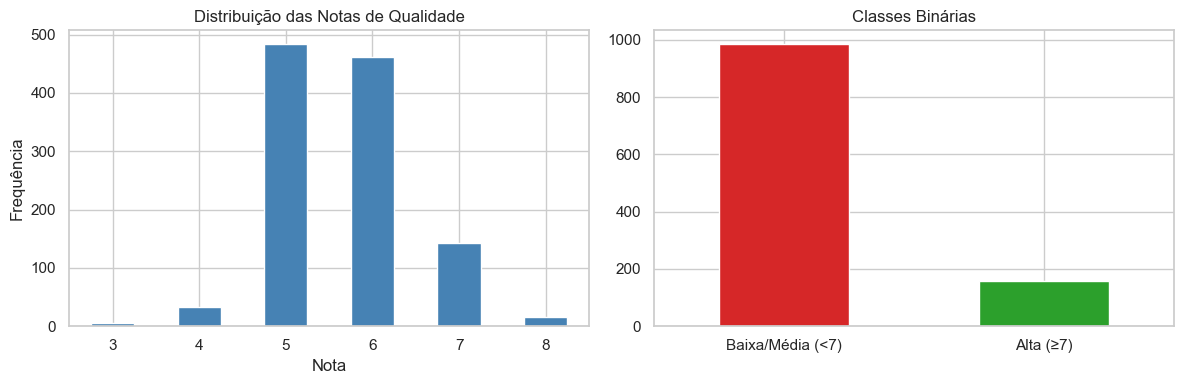

In [9]:
# Criando a classificação binária
df['quality_label'] = df['quality'].apply(lambda x: 'Alta (≥7)' if x >= 7 else 'Baixa/Média (<7)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição original
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição das Notas de Qualidade')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=0)

# Distribuição binária
df['quality_label'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#d62728', '#2ca02c'], edgecolor='white')
axes[1].set_title('Classes Binárias')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


> **Observação:** O dataset é desbalanceado — cerca de **86% das amostras** pertencem à classe Baixa/Média e apenas **14% à Alta Qualidade**. Isso deverá ser tratado no pré-processamento.


### 3.3 Distribuição das Features

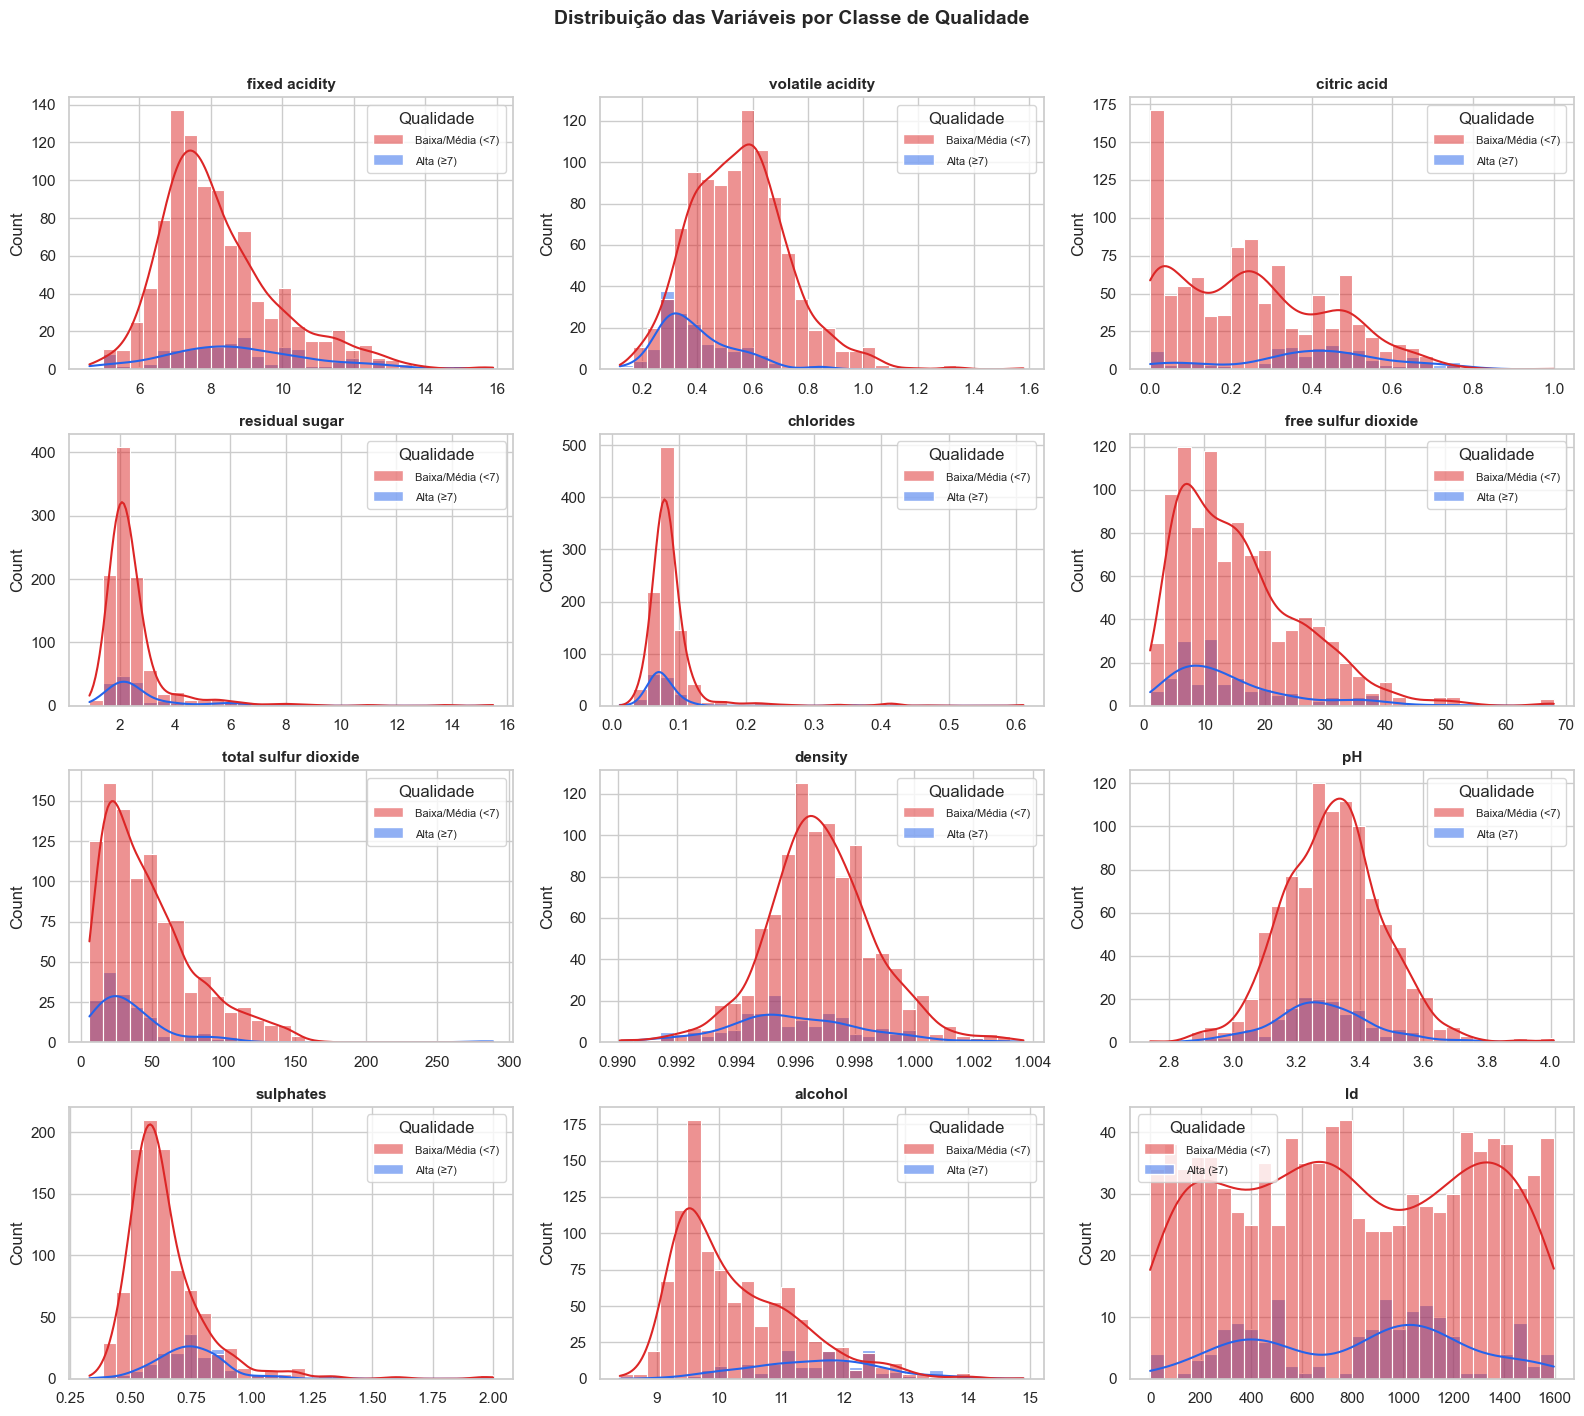

In [12]:
df['quality_label'] = df['quality'].apply(lambda x: 'Alta (≥7)' if x >= 7 else 'Baixa/Média (<7)')

features = [c for c in df.columns if c not in ['quality', 'quality_label', 'wine_type']]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.histplot(
        data=df, x=col, hue='quality_label',
        kde=True, ax=ax,
        palette={'Alta (≥7)': '#2563EB', 'Baixa/Média (<7)': '#DC2626'},
        alpha=0.5, bins=30
    )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    
    # Pega a legenda que o seaborn criou e ajusta o título
    legend = ax.get_legend()
    if legend:
        legend.set_title('Qualidade')
        for text in legend.get_texts():
            text.set_fontsize(8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis por Classe de Qualidade', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<Axes: >

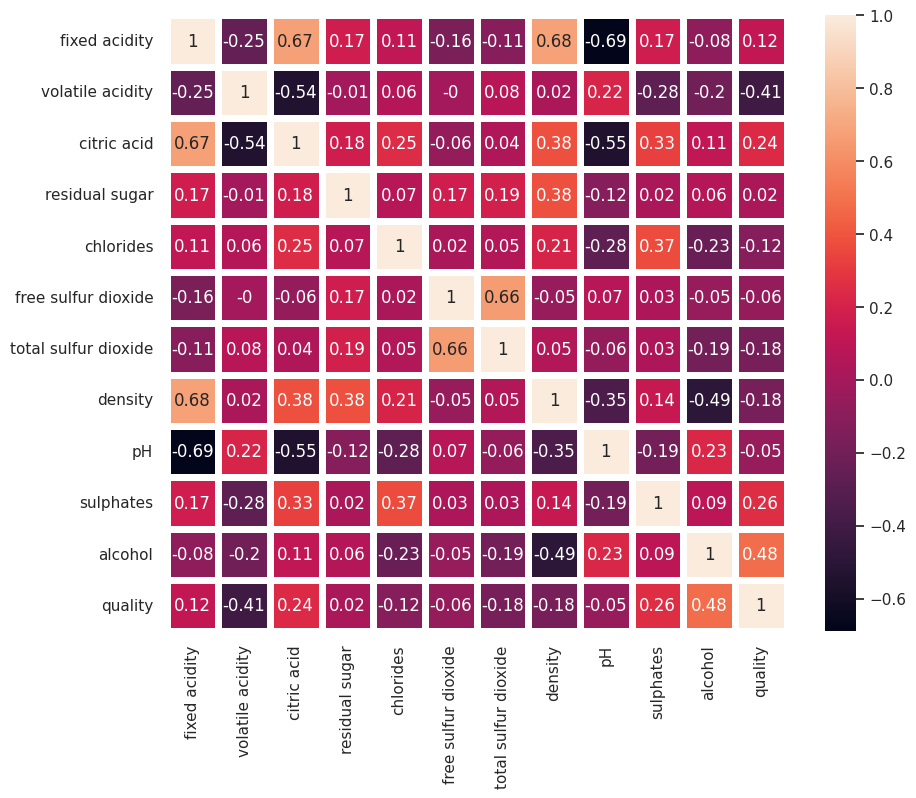

In [ ]:
import seaborn as sb
correlation_matriz = df.drop(columns=['quality_label']).corr().round(2)
fix, ax = plt.subplots(figsize=(10, 8))
sb.heatmap(data = correlation_matriz, annot=True, linewidths=5, ax=ax)

### 3.4 Matriz de Correlação

### 3.5 Boxplots por Classe

/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplo

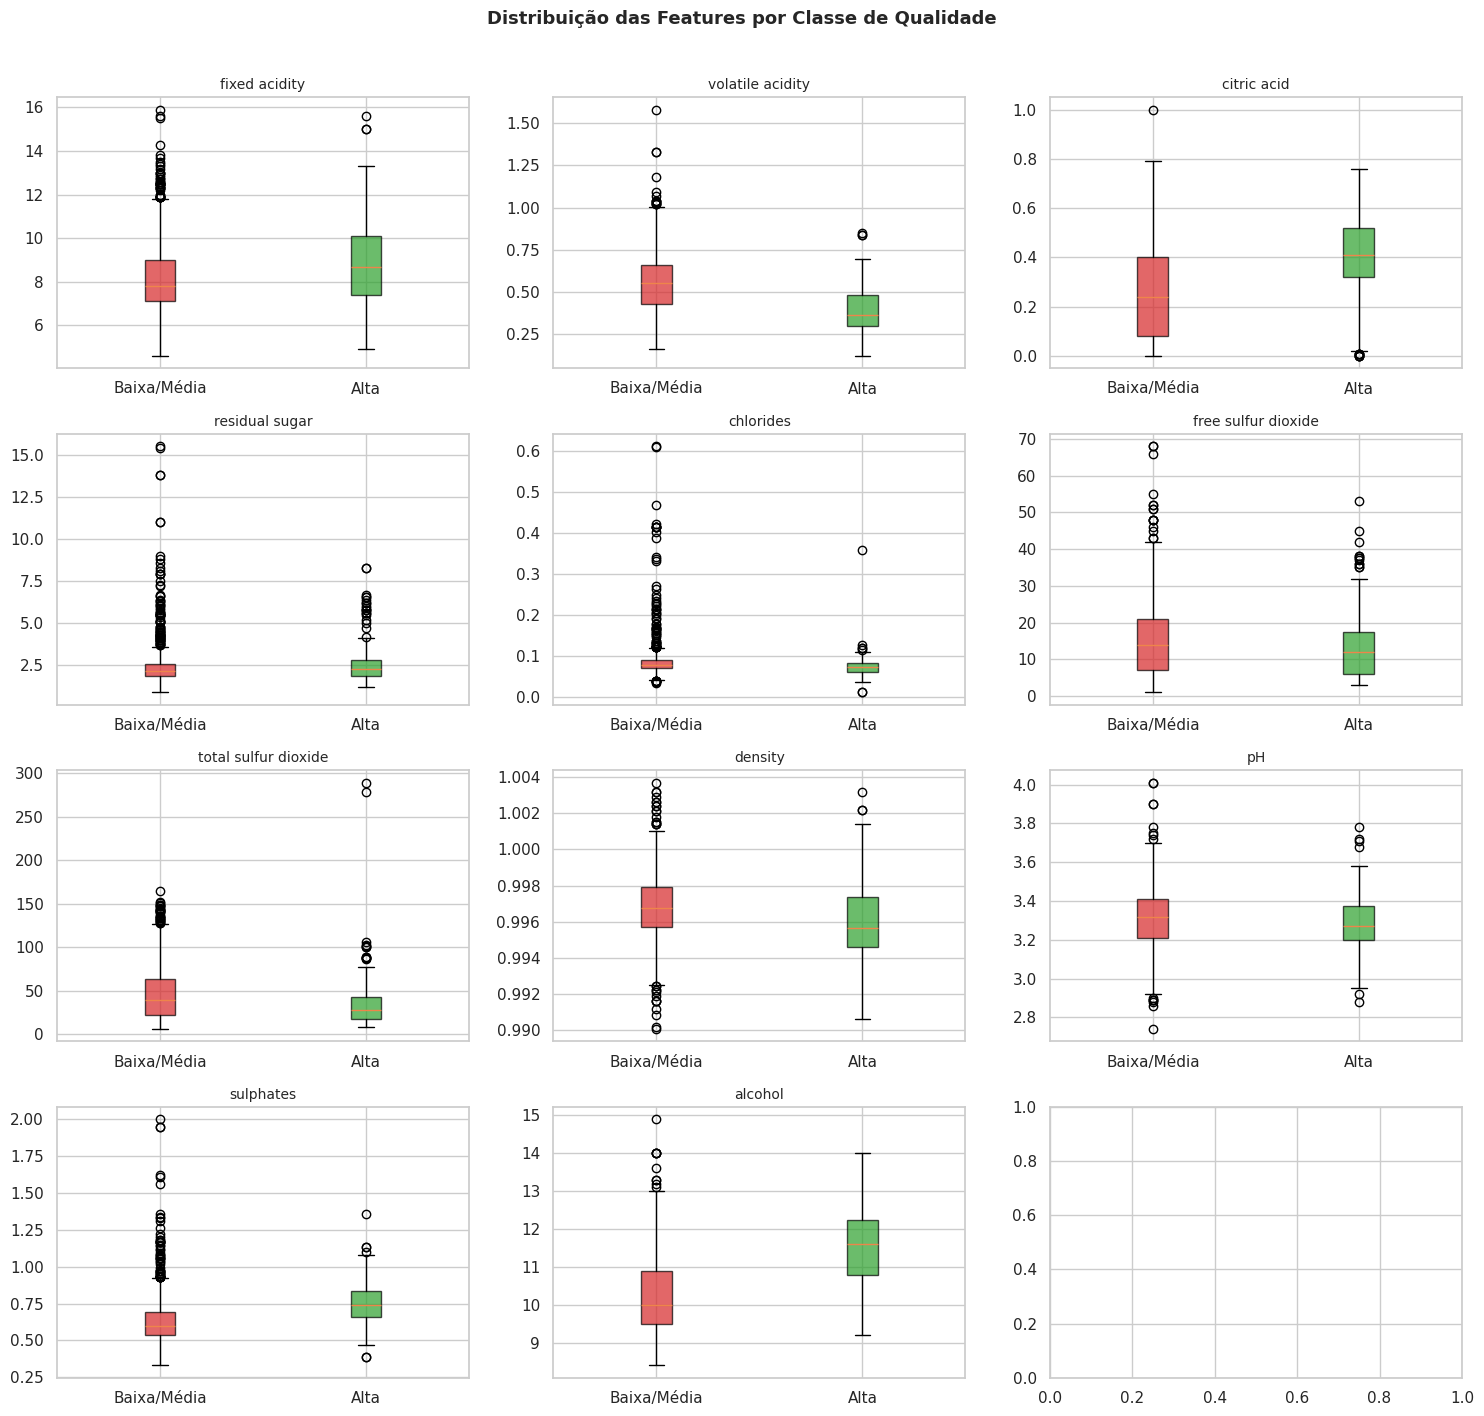

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = [df[df['quality_label'] == cls][feat].values for cls in ['Baixa/Média (<7)', 'Alta (≥7)']]
    bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
    bp['boxes'][0].set(facecolor='#d62728', alpha=0.7)
    bp['boxes'][1].set(facecolor='#2ca02c', alpha=0.7)
    axes[i].set_title(feat, fontsize=10)

plt.suptitle('Distribuição das Features por Classe de Qualidade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.6 Principais Insights da EDA

In [ ]:
corr_quality = corr['quality'].drop('quality').sort_values(ascending=False)

print("=" * 60)
print("PRINCIPAIS INSIGHTS — ANÁLISE EXPLORATÓRIA")
print("=" * 60)

print(f"\n📌 Dataset: {df.shape[0]} amostras | {df.shape[1]-2} features | sem valores nulos")

print("\n📊 Balanceamento das classes:")
vc = df['quality_label'].value_counts()
for label, count in vc.items():
    print(f"   {label}: {count} ({count/len(df)*100:.1f}%)")
print("   → Desbalanceamento tratado via stratify no split treino/teste")

print("\n🔗 Correlação com a qualidade (ordenada):")
for feat, val in corr_quality.items():
    barra = '█' * int(abs(val) * 15)
    sinal = '+' if val >= 0 else '-'
    print(f"   {sinal} {feat:<25} {val:+.3f}  {barra}")

print("\n💡 Destaques:")
print(f"   • Maior correlação positiva: '{corr_quality.idxmax()}' ({corr_quality.max():+.3f})")
print(f"   • Maior correlação negativa: '{corr_quality.idxmin()}' ({corr_quality.min():+.3f})")

# Par com maior multicolinearidade
max_pair = (None, None, 0)
for i, c1 in enumerate(features):
    for j, c2 in enumerate(features):
        if j <= i:
            continue
        v = abs(corr.loc[c1, c2])
        if v > max_pair[2]:
            max_pair = (c1, c2, v)
print(f"   • Maior multicolinearidade: '{max_pair[0]}' × '{max_pair[1]}' ({max_pair[2]:.3f})")


PRINCIPAIS INSIGHTS — ANÁLISE EXPLORATÓRIA

📌 Dataset: 1143 amostras | 11 features | sem valores nulos

📊 Balanceamento das classes:
   Baixa/Média (<7): 984 (86.1%)
   Alta (≥7): 159 (13.9%)
   → Desbalanceamento tratado via stratify no split treino/teste

🔗 Correlação com a qualidade (ordenada):
   + alcohol                   +0.485  ███████
   + sulphates                 +0.258  ███
   + citric acid               +0.241  ███
   + fixed acidity             +0.122  █
   + residual sugar            +0.022  
   - pH                        -0.052  
   - free sulfur dioxide       -0.063  
   - chlorides                 -0.124  █
   - density                   -0.175  ██
   - total sulfur dioxide      -0.183  ██
   - volatile acidity          -0.407  ██████

💡 Destaques:
   • Maior correlação positiva: 'alcohol' (+0.485)
   • Maior correlação negativa: 'volatile acidity' (-0.407)
   • Maior multicolinearidade: 'fixed acidity' × 'pH' (0.685)


### 3.6 Boxplots por Classe

/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_34143/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplo

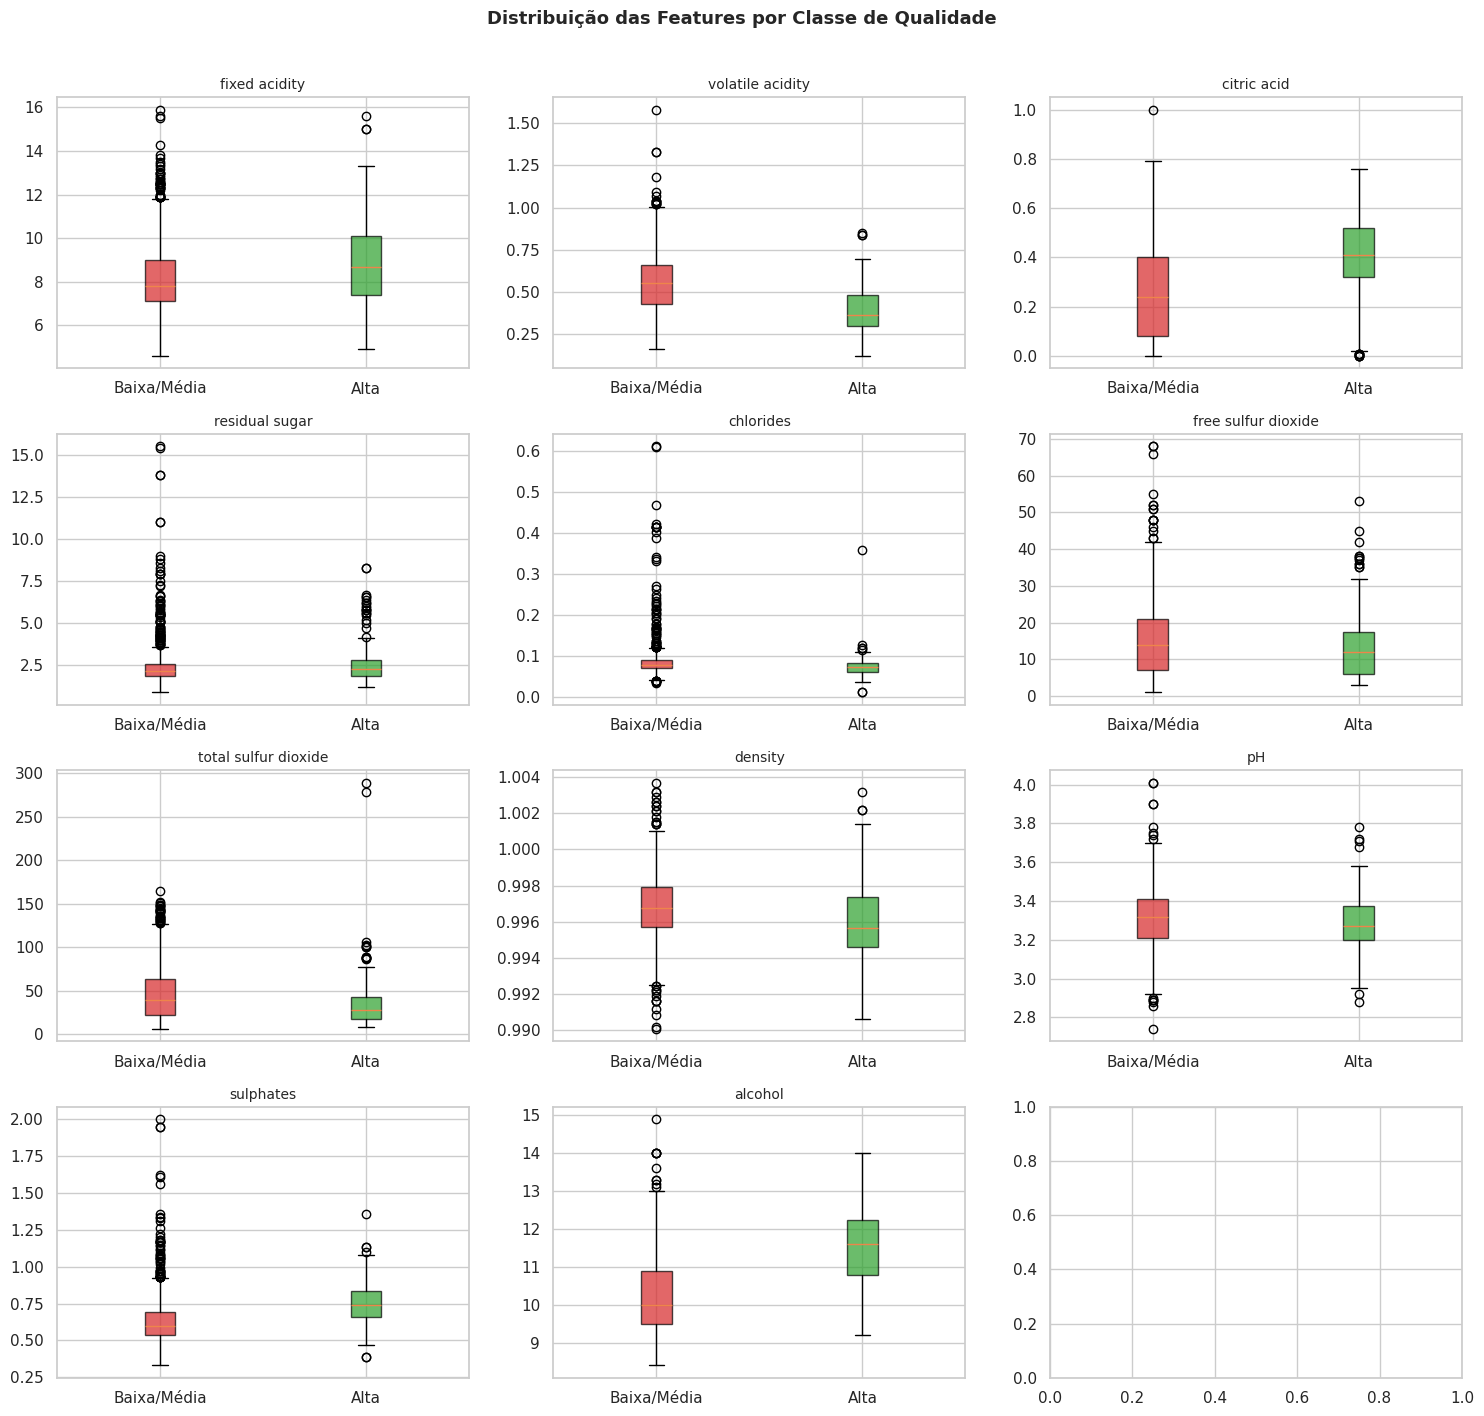

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = [df[df['quality_label'] == cls][feat].values for cls in ['Baixa/Média (<7)', 'Alta (≥7)']]
    bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
    bp['boxes'][0].set(facecolor='#d62728', alpha=0.7)
    bp['boxes'][1].set(facecolor='#2ca02c', alpha=0.7)
    axes[i].set_title(feat, fontsize=10)

plt.suptitle('Distribuição das Features por Classe de Qualidade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.7 Outliers

In [ ]:
print(f"{'Feature':<30} {'Outliers':>10} {'%':>8}")
print("-" * 52)
for feat in features:
    Q1, Q3 = df[feat].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    print(f"  {feat:<28} {n:>10} {n/len(df)*100:>7.1f}%")


Feature                          Outliers        %
----------------------------------------------------
  fixed acidity                        44     3.8%
  volatile acidity                     14     1.2%
  citric acid                           1     0.1%
  residual sugar                      110     9.6%
  chlorides                            77     6.7%
  free sulfur dioxide                  18     1.6%
  total sulfur dioxide                 40     3.5%
  density                              36     3.1%
  pH                                   20     1.7%
  sulphates                            43     3.8%
  alcohol                              12     1.0%
